In [ ]:
#Instalación del paquete tabulate para imprimir la matriz de confusión
!pip install tabulate

In [ ]:
!pip install -U -q PyDrive

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import pylab as pl
from matplotlib import pyplot as plt
from sklearn import preprocessing
from sklearn import datasets
from sklearn.metrics import confusion_matrix
from tabulate import tabulate
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Función para visualizar un conjunto de datos en 2D
def plot_data(X, y, size=None):
    y_unique = np.unique(y)
    colors = pl.cm.rainbow(np.linspace(0.0, 1.0, y_unique.size))
    for this_y, color in zip(y_unique, colors):
        this_X = X[y == this_y]
        pl.scatter(this_X[:, 0], this_X[:, 1],  c=color,
                    alpha=0.5, edgecolor='k', s=size,
                    label="Class %s" % this_y)
    pl.legend(loc="best")
    pl.title("Data")

# Función para visualizar de la superficie de decisión de un clasificador
def plot_decision_region2(X, pred_fun):      #Función para visualizar la superficie de decisión de nuestro algoritmo.
    min_x = np.min(X[:, 0])
    max_x = np.max(X[:, 0])
    min_y = np.min(X[:, 1])
    max_y = np.max(X[:, 1])
    min_x = min_x - (max_x - min_x) * 0.05
    max_x = max_x + (max_x - min_x) * 0.05
    min_y = min_y - (max_y - min_y) * 0.05
    max_y = max_y + (max_y - min_y) * 0.05
    x_vals = np.linspace(min_x, max_x, 100)
    y_vals = np.linspace(min_y, max_y, 100)
    XX, YY = np.meshgrid(x_vals, y_vals)
    grid_r, grid_c = XX.shape
    ZZ = np.zeros((grid_r, grid_c))
    for i in range(grid_r):
        for j in range(grid_c):
            ZZ[i, j] = pred_fun(XX[i, j], YY[i, j])
    pl.contourf(XX, YY, ZZ, 100, cmap = pl.cm.coolwarm, vmin= 0, vmax=1)
    pl.colorbar()
    pl.xlabel("x")
    pl.ylabel("y")

def gen_pred_fun(clf):
    def pred_fun(x1, x2):
        x = np.array([[x1, x2]])
        return clf.predict(x)[0]
    return pred_fun

def list_cm(cm,classes):     #función para generar de una forma más visual la matriz de confusión
    if len(cm)==2:
      cm.astype(int)
      row_0 =['','Valor','Verdadero']
      row_1 =['-',classes[0],classes[1]]
      row_2 =[classes[0],cm[0,0],cm[1,0]]
      row_3 =[classes[1],cm[0,1],cm[1,1]]
      table = zip(row_0,row_1, row_2, row_3)
      headers = ['', '', 'Valor', 'Predicho']
      return print(tabulate(table, headers=headers, floatfmt=".0f"))
    else:
      cm.astype(int)
      row_0 =['','Valor','Verdadero','']
      row_1 =['-',np.int(classes[0]),classes[1],classes[2]]
      row_2 =[classes[0],cm[0,0],cm[1,0],cm[2,0]]
      row_3 =[classes[1],cm[0,1],cm[1,1],cm[2,1]]
      row_4 =[classes[2],cm[0,2],cm[1,2],cm[2,2]]
      table = zip(row_0,row_1, row_2, row_3, row_4)
      headers = ['', '', 'Valor', 'Predicho', '']
      return print(tabulate(table, headers=headers, floatfmt=".0f"))

In [ ]:
import numpy as np
import random

class Perceptron(object):
    def __init__(self, n=0.01, n_iter=500):
      self.n = n
      self.n_iter = n_iter

    def fit(self, X, y):
      self.w_ = np.zeros(1 + X.shape[1])
      self.errors_ = np.zeros(self.n_iter)
      for i in range(self.n_iter):
        for xi, yi in zip(X, y):
          update = self.n * (yi - self.predict(xi))
          self.errors_[i] += 0.5*(yi - self.predict(xi))**2
          self.w_[1:] += update * xi
          self.w_[0] += -update
      return self

    def initSet(self, X):
      self.w_ = np.zeros(1 + X.shape[1])
      self.w_[0] = 0
      self.w_[1] = 0
      self.w_[2] = 0
      return self

    def net_input(self, X):
      return np.dot(X, self.w_[1:]) - self.w_[0]

    def predict(self, X):
      p = 1/(1 + np.exp(-self.net_input(X)))
      #i = random.uniform(0,1)
      return np.where(p >= 0.5, 1, -1)

## Ejemplo a mano


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


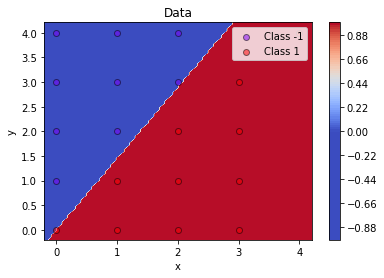

In [ ]:
X = np.array([[0, 0], [2, 1], [1, 0], [2, 0], [3, 0], [1, 1], [3, 1], [3, 2], [2, 2], [3, 3],
              [0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3], [0, 4], [1, 4], [2, 4], [4, 4]])
y = [1,1,1,1,1,1,1,1,1,1,-1,-1,-1,-1,-1,-1,-1,-1,-1,1]


classifier = Perceptron(n=0.01, n_iter=100).fit(X,y)
w = classifier.w_
funcion = gen_pred_fun(classifier)
plot_decision_region2(X,funcion)
plot_data(X,y)

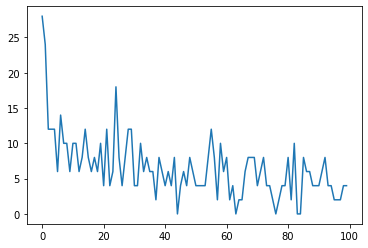

In [ ]:
plt.plot(classifier.errors_)

##Cargar datos de un archivo

In [ ]:
#datos = pd.read_csv('datos.txt')
#array = np.array(datos)
#del datos
#X2 = array[:,[1,2]]
#y2 = array[:,0]
#X2[:,0] = (X2[:,0] - X2[:,0].mean()) / X2[:,0].std()
#X2[:,1] = (X2[:,1] - X2[:,1].mean()) / X2[:,1].std()

#classifier2 = Perceptron(n=0.01, n_iter=20).fit(X2,y2)
#w2 = classifier2.w_
#funcion = gen_pred_fun(classifier2)
#plot_decision_region2(X2,funcion)
#plot_data(X2,y2)

In [ ]:
#plt.plot(classifier2.errors_)

##Datos generados aleatoriamente

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


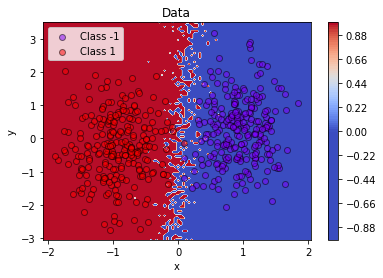

In [ ]:
from sklearn.datasets import make_blobs
X1, y1 = make_blobs(n_samples=500, centers=2, n_features=2, random_state=80)
X1[:,0] = (X1[:,0] - X1[:,0].mean()) / X1[:,0].std()
X1[:,1] = (X1[:,1] - X1[:,1].mean()) / X1[:,1].std()

for i in range(len(y1)):
  if y1[i] == 0:
     y1[i] = -1

classifier1 = Perceptron(n=0.01, n_iter=100).fit(X1,y1)
w1 = classifier1.w_
funcion1 = gen_pred_fun(classifier1)
plot_decision_region2(X1,funcion1)
plot_data(X1,y1)

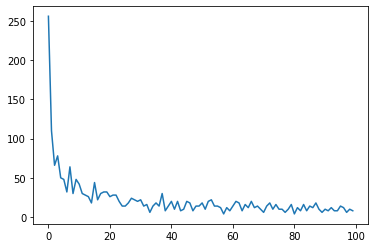

In [ ]:
plt.plot(classifier1.errors_)